In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curves_with_variability():
    base_dirs = {
        # 'Combined': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both/{cell_type}',
        # 'Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes/{cell_type}',
        'Demo + APOE': "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_Total_Demo_new",
        'Combined': "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_Total_Demographics_Genes_new"
    }

    colors = {
        # 'Combined': 'black',
        'Combined': 'blue',
        'Demo + APOE': 'red'
    }

    plt.figure(figsize=(8, 6))
    mean_fpr = np.linspace(0, 1, 100)

    for label, base_path in base_dirs.items():
        all_tprs = []
        aucs = []

        for i in range(1, 6):
            pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
            if not os.path.exists(pred_file):
                continue

            df = pd.read_csv(pred_file)
            y_true = df['true_label']
            y_score = df['predicted_proba']
            fpr, tpr, _ = roc_curve(y_true, y_score)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            all_tprs.append(interp_tpr)
            aucs.append(auc(fpr, tpr))

            plt.plot(fpr, tpr, color=colors[label], alpha=0.2)

        if all_tprs:
            mean_tpr = np.mean(all_tprs, axis=0)
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            plt.plot(mean_fpr, mean_tpr, color=colors[label], linewidth=2.5,
                     label=f'{label} (AUC: {mean_auc:.3f} ± {std_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title("Global Classifier", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11, frameon=True)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save figure
    save_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure1/"
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, "both_in_one_global_classifier_roc_curve.png"), dpi=300, bbox_inches='tight')

    # Also show it
    plt.show()

    plt.close()

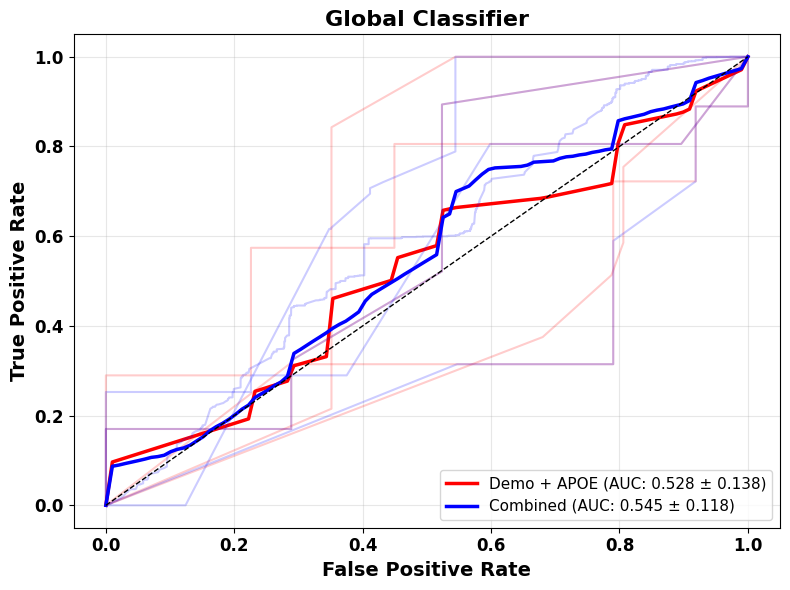

In [19]:
plot_roc_curves_with_variability()

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curves_with_variability():
    base_dirs = {
        # 'Combined': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both/{cell_type}',
        # 'Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes/{cell_type}',
        'Classifier Mean': "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_Total_Demographics_Genes_new",
    }

    colors = {
        # 'Combined': 'black',
        # 'Genes': 'blue',
        'Classifier Mean': 'red'
    }

    plt.figure(figsize=(8, 6))
    mean_fpr = np.linspace(0, 1, 100)

    for label, base_path in base_dirs.items():
        all_tprs = []
        aucs = []

        for i in range(1, 6):
            pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
            if not os.path.exists(pred_file):
                continue

            df = pd.read_csv(pred_file)
            y_true = df['true_label']
            y_score = df['predicted_proba']
            fpr, tpr, _ = roc_curve(y_true, y_score)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            all_tprs.append(interp_tpr)
            aucs.append(auc(fpr, tpr))

            plt.plot(fpr, tpr, color=colors[label], alpha=0.2)

        if all_tprs:
            mean_tpr = np.mean(all_tprs, axis=0)
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            plt.plot(mean_fpr, mean_tpr, color=colors[label], linewidth=2.5,
                     label=f'{label} (AUC: {mean_auc:.3f} ± {std_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title("Demographics, APOE, and Gene Expression Classifier", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11, frameon=True)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save figure
    save_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure1/"
    plt.savefig(os.path.join(save_dir, "combined_global_classifier_roc_curve.png"), dpi=300, bbox_inches='tight')


    # Also show it
    plt.show()

    plt.close()

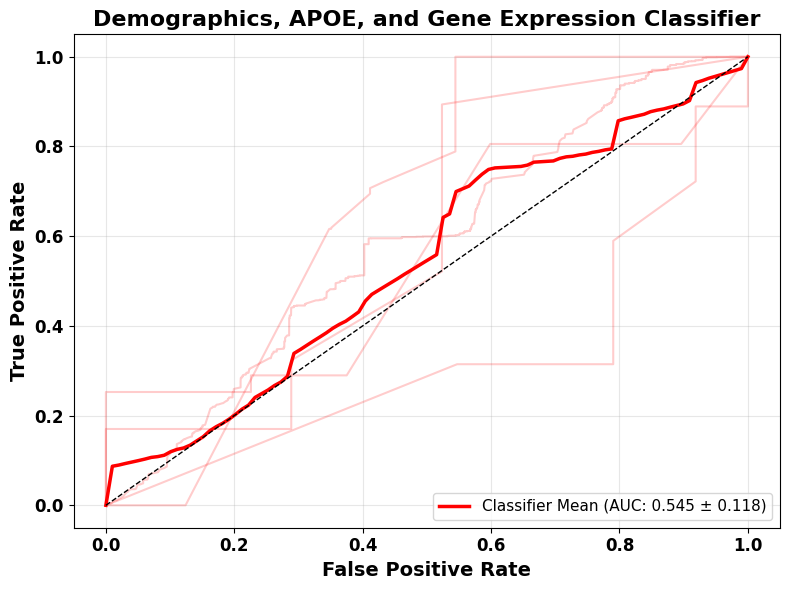

In [10]:
plot_roc_curves_with_variability()